In [2]:
# ====== Cell 1: 导入 ======
import tensorflow as tf
from tensorflow.keras import layers
import numpy as np

print(f"TensorFlow: {tf.__version__}")

TensorFlow: 2.21.0


In [4]:
# ====== Cell 2: 上传数据 ======
# 方法一：从 Google Drive 加载（推荐）

# 把 dataset/ 文件夹上传到 Drive，改下面的路径
DATASET_PATH = r"C:\Users\hongy\Desktop\ee474\ee474\dataset"

# 方法二：直接上传 zip
# from google.colab import files
# uploaded = files.upload()  # 上传 dataset.zip
# !unzip dataset.zip
# DATASET_PATH = "dataset"

In [10]:
# ====== Cell 3: 加载数据 ======
IMG_SIZE = 96
BATCH_SIZE = 8  # 数据少用小 batch

train_ds = tf.keras.utils.image_dataset_from_directory(
    DATASET_PATH,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    validation_split=0.2,
    subset="training",
    seed=42
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    DATASET_PATH,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    validation_split=0.2,
    subset="validation",
    seed=42
)

class_names = train_ds.class_names
print(f"Classes: {class_names}")  # ['empty', 'occupied']
print(f"Training batches: {len(train_ds)}")
print(f"Validation batches: {len(val_ds)}")

Found 205 files belonging to 2 classes.
Using 164 files for training.
Found 205 files belonging to 2 classes.
Using 41 files for validation.
Classes: ['empty', 'occupied']
Training batches: 21
Validation batches: 6


In [11]:
# ====== Cell 4: 数据增强 + 归一化 ======
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomBrightness(0.2),
    layers.RandomContrast(0.2),
])

normalize = layers.Rescaling(1./255)

train_ds = train_ds.map(lambda x, y: (normalize(data_augmentation(x, training=True)), y))
val_ds = val_ds.map(lambda x, y: (normalize(x), y))

train_ds = train_ds.prefetch(tf.data.AUTOTUNE)
val_ds = val_ds.prefetch(tf.data.AUTOTUNE)

In [12]:
# ====== Cell 5: 定义模型 ======
model = tf.keras.Sequential([
    layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3)),

    # Block 1: 96x96x3 → 48x48x8
    layers.Conv2D(8, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),

    # Block 2: 48x48x8 → 24x24x16
    layers.Conv2D(16, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),

    # Block 3: 24x24x16 → 12x12x32
    layers.Conv2D(32, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),

    # 分类头
    layers.GlobalAveragePooling2D(),  # 12x12x32 → 32
    layers.Dense(16, activation='relu'),
    layers.Dense(2, activation='softmax')
])

model.summary()

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 96, 96, 8)      │           224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 48, 48, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 48, 48, 16)     │         1,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 24, 24, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 24, 24, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 12, 12, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 32)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 2)              │            34 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,594 (25.76 KB)

 Trainable params: 6,594 (25.76 KB)

 Non-trainable params: 0 (0.00 B)

In [15]:
# Cell 6: 降学习率 + 增加 epochs
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0002),  # 默认 0.001 太大
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=80  # 多跑一些，让它慢慢收敛
)
print(f"\nFinal val accuracy: {history.history['val_accuracy'][-1]:.2%}")

Epoch 1/80
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.9024 - loss: 0.2696 - val_accuracy: 0.9512 - val_loss: 0.2453
Epoch 2/80
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9024 - loss: 0.2565 - val_accuracy: 0.9268 - val_loss: 0.2597
Epoch 3/80
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9329 - loss: 0.2413 - val_accuracy: 0.9512 - val_loss: 0.2456
Epoch 4/80
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9329 - loss: 0.2427 - val_accuracy: 0.9512 - val_loss: 0.2400
Epoch 5/80
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9268 - loss: 0.2430 - val_accuracy: 0.9512 - val_loss: 0.2353
Epoch 6/80
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9024 - loss: 0.2311 - val_accuracy: 0.9512 - val_loss: 0.2316
Epoch 7/80
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9085 - loss: 0.2539 - val_accuracy: 0.9268 - val_loss: 0.2523
Epoch 8/80
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9573 - loss: 0.2085 - val_accuracy: 0.9268 - val_l

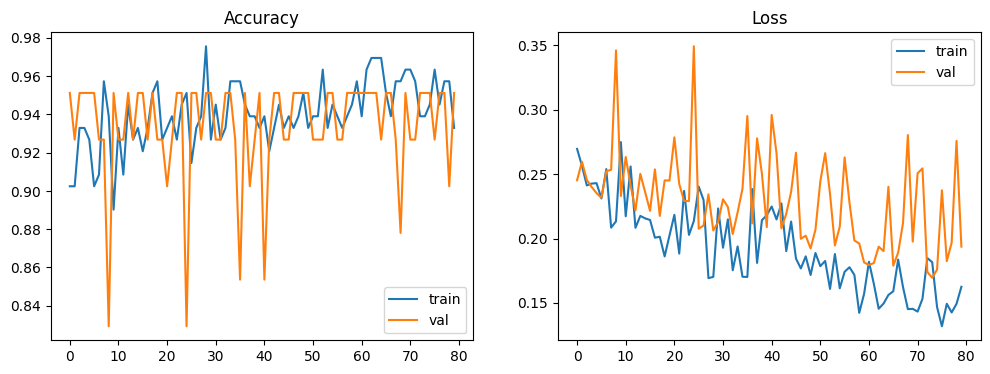

In [16]:
# ====== Cell 7: 看训练曲线 ======
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(history.history['accuracy'], label='train')
ax1.plot(history.history['val_accuracy'], label='val')
ax1.set_title('Accuracy')
ax1.legend()

ax2.plot(history.history['loss'], label='train')
ax2.plot(history.history['val_loss'], label='val')
ax2.set_title('Loss')
ax2.legend()

plt.show()

# 如果 val_accuracy > 90% 就够用了
# 如果 train 高 val 低 = 过拟合，减少 epochs 或加更多 augmentation

In [17]:
# ====== Cell 8: INT8 量化 ======
def representative_dataset():
    for images, _ in train_ds.take(50):
        for i in range(images.shape[0]):
            yield [np.expand_dims(images[i].numpy(), axis=0).astype(np.float32)]

converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.representative_dataset = representative_dataset
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter.inference_input_type = tf.int8
converter.inference_output_type = tf.int8

tflite_model = converter.convert()

with open("parking_model.tflite", "wb") as f:
    f.write(tflite_model)

print(f"Float32 model: {model.count_params() * 4 / 1024:.1f} KB")
print(f"INT8 model:    {len(tflite_model) / 1024:.1f} KB")

INFO:tensorflow:Assets written to: C:\Users\hongy\AppData\Local\Temp\tmpvi7cwt6z\assets


INFO:tensorflow:Assets written to: C:\Users\hongy\AppData\Local\Temp\tmpvi7cwt6z\assets


Saved artifact at 'C:\Users\hongy\AppData\Local\Temp\tmpvi7cwt6z'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 96, 96, 3), dtype=tf.float32, name='keras_tensor_18')
Output Type:
  TensorSpec(shape=(None, 2), dtype=tf.float32, name=None)
Captures:
  2170511354640: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2170511350608: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2170511350032: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2170511355216: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2169790733136: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2170511350416: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2170511353872: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2170511354256: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2170511350800: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2170511348496: TensorSpec(shape=(), dtype=tf.resource, name=None)


c:\Users\hongy\AppData\Local\Programs\Python\Python312\Lib\site-packages\tensorflow\lite\python\convert.py:846: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(


Float32 model: 25.8 KB
INT8 model:    13.5 KB


In [18]:
# ====== Cell 9: 验证量化模型 ======
interpreter = tf.lite.Interpreter(model_content=tflite_model)
interpreter.allocate_tensors()

input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

print(f"Input shape:  {input_details[0]['shape']}")
print(f"Input dtype:  {input_details[0]['dtype']}")
print(f"Input quant:  {input_details[0]['quantization']}")
print(f"Output shape: {output_details[0]['shape']}")
print(f"Output dtype: {output_details[0]['dtype']}")
print(f"Output quant: {output_details[0]['quantization']}")

# 用几张验证图测一下
correct = 0
total = 0
for images, labels in val_ds:
    for i in range(images.shape[0]):
        img = images[i].numpy()
        # float → int8
        scale, zero_point = input_details[0]['quantization']
        img_int8 = (img / scale + zero_point).astype(np.int8)
        interpreter.set_tensor(input_details[0]['index'],
                               np.expand_dims(img_int8, axis=0))
        interpreter.invoke()
        output = interpreter.get_tensor(output_details[0]['index'])
        pred = np.argmax(output[0])
        if pred == labels[i].numpy():
            correct += 1
        total += 1

print(f"\nINT8 model accuracy: {correct/total:.2%}")

Input shape:  [ 1 96 96  3]
Input dtype:  <class 'numpy.int8'>
Input quant:  (0.003921568859368563, -128)
Output shape: [1 2]
Output dtype: <class 'numpy.int8'>
Output quant: (0.00390625, -128)

INT8 model accuracy: 95.12%


c:\Users\hongy\AppData\Local\Programs\Python\Python312\Lib\site-packages\tensorflow\lite\python\interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


In [19]:
# ====== Cell 10: 导出 C 头文件 ======
hex_array = ', '.join([f'0x{b:02x}' for b in tflite_model])
header = f"""// Auto-generated TFLite model for parking detection
// Model size: {len(tflite_model)} bytes
// Input: 96x96x3 INT8
// Output: 2 classes [empty, occupied]
// Quantization params — check Cell 9 output

#ifndef PARKING_MODEL_H
#define PARKING_MODEL_H

alignas(8) const unsigned char model_data[] = {{{hex_array}}};
const unsigned int model_data_len = {len(tflite_model)};

#endif
"""

with open("parking_model.h", "w") as f:
    f.write(header)

print(f"Header file size: {len(header) / 1024:.1f} KB")

Header file size: 81.1 KB
